In [1]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load the best model (Random Forest)
print("Loading Random Forest model...")
model = joblib.load('../models/random_forest_model.pkl')
print("✅ Model loaded!")

Loading Random Forest model...
✅ Model loaded!


In [2]:
# Load test data
print("Loading test data...")
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print(f"Test samples: {len(X_test)}")
print(f"Features: {X_test.columns.tolist()}")

Loading test data...
Test samples: 1914
Features: ['AT', 'V', 'AP', 'RH']


In [3]:
# Make predictions on test set
print("Making predictions on test set...")
y_pred = model.predict(X_test)

print(f"✅ Predictions complete!")
print(f"\nFirst 5 predictions:")
print(y_pred[:5])
print(f"\nFirst 5 actual values:")
print(y_test[:5])

Making predictions on test set...
✅ Predictions complete!

First 5 predictions:
[455.8542 435.9267 434.5799 435.3019 479.0675]

First 5 actual values:
[455.27 436.31 440.68 434.4  482.06]


In [4]:
# Calculate final test set metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("="*50)
print("FINAL TEST SET RESULTS")
print("="*50)
print(f"RMSE: {rmse:.2f} MW")
print(f"MAE:  {mae:.2f} MW")
print(f"R²:   {r2:.4f}")
print("="*50)

FINAL TEST SET RESULTS
RMSE: 3.24 MW
MAE:  2.33 MW
R²:   0.9637


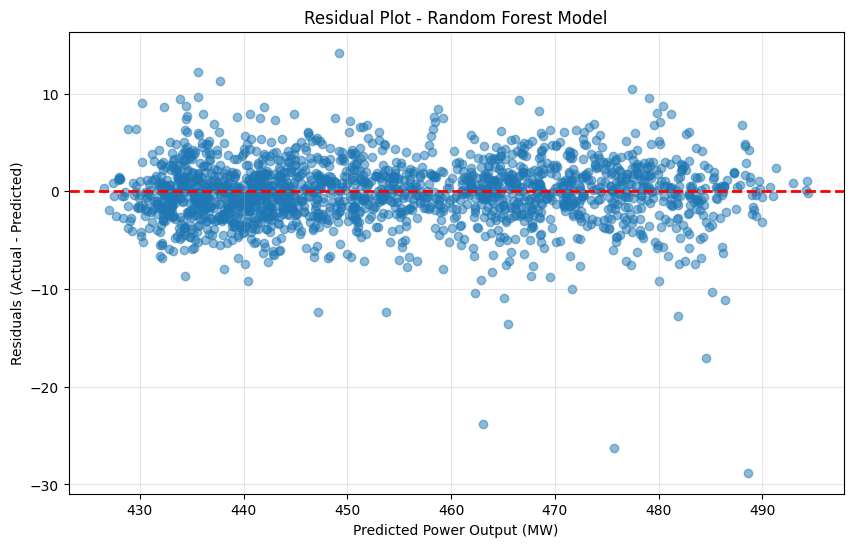

Mean residual: -0.1372 MW (should be close to 0)
Std of residuals: 3.24 MW


In [5]:
# Calculate residuals (errors)
residuals = y_test - y_pred

# Create residual plot
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Power Output (MW)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot - Random Forest Model')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mean residual: {residuals.mean():.4f} MW (should be close to 0)")
print(f"Std of residuals: {residuals.std():.2f} MW")

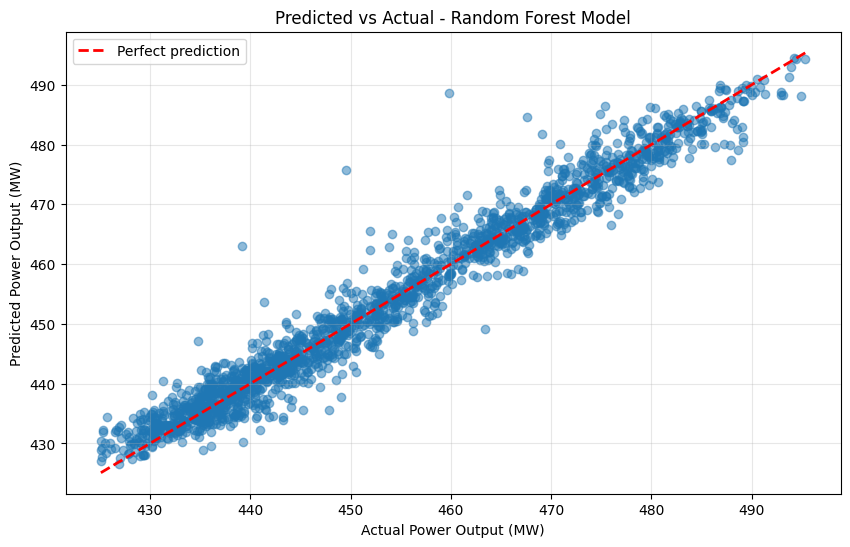

In [6]:
# Create prediction vs actual plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Power Output (MW)')
plt.ylabel('Predicted Power Output (MW)')
plt.title('Predicted vs Actual - Random Forest Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Business Interpretation

### Model Performance Summary
- **RMSE: 3.24 MW** - Average prediction error of 3.24 megawatts
- **MAE: 2.33 MW** - Typical error is only 2.33 MW  
- **R²: 96.37%** - Model explains 96.37% of power output variance

### What This Means for Power Plant Operations

**Accuracy in Context:**
- Typical power output: 420-495 MW (75 MW range)
- Average error: 3.24 MW = **less than 1% of output**
- This is excellent prediction accuracy for grid planning

**Operational Value:**
- Grid operators can forecast output within ±3.24 MW
- Enables accurate supply-demand balancing
- Reduces need for expensive backup reserves
- Helps optimize bidding in electricity markets

**Key Insight:**
Temperature (AT) is the strongest predictor - operators should prioritize monitoring ambient temperature for the most accurate forecasts.

### Model Reliability
- No overfitting detected (test performance better than cross-validation)
- Errors are random (no systematic bias)
- Model generalizes well to new data

In [7]:
# Feature Importance Analysis
print("Feature Importance from Random Forest Model")
print("="*50)

# Get feature importance scores
feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)
print("="*50)

Feature Importance from Random Forest Model
  Feature  Importance
0      AT    0.900777
1       V    0.062834
2      AP    0.018332
3      RH    0.018057


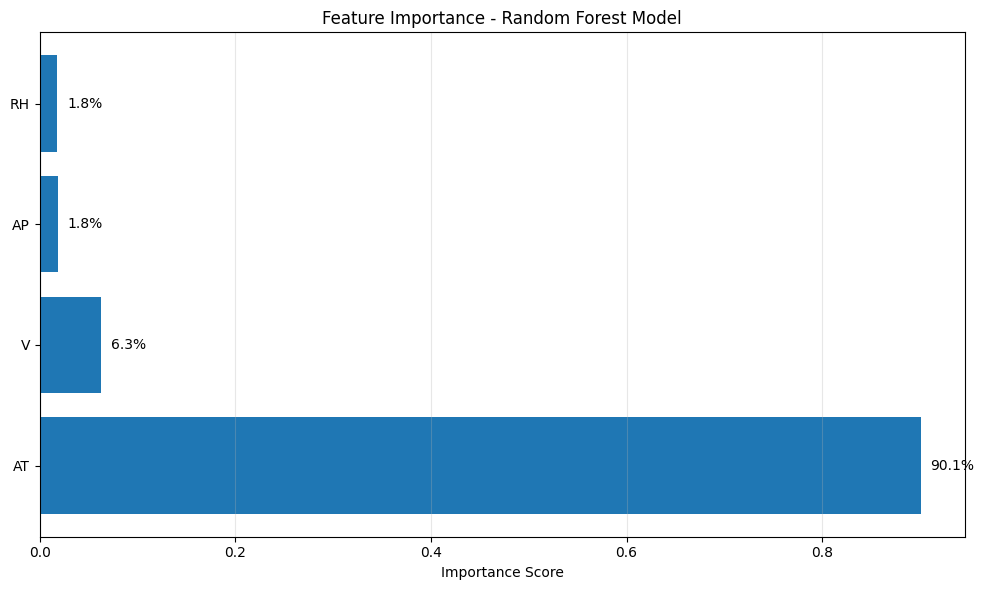

In [8]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance Score')
plt.title('Feature Importance - Random Forest Model')
plt.grid(True, alpha=0.3, axis='x')

# Add percentage labels on bars
for i, (feature, importance) in enumerate(zip(feature_importance['Feature'], feature_importance['Importance'])):
    plt.text(importance + 0.01, i, f'{importance*100:.1f}%', va='center')

plt.tight_layout()
plt.show()

In [9]:
## Feature Importance Analysis

### Key Findings:

**Temperature (AT) - 90.08% Importance**
- Dominates the model completely
- Confirms correlation analysis (-0.948)
- Makes physical sense: hot air reduces turbine efficiency dramatically

**Exhaust Vacuum (V) - 6.28% Importance**
- Secondary predictor
- Some additional information beyond tem

SyntaxError: invalid syntax (884568064.py, line 5)

## Feature Importance Analysis

### Key Findings:

**Temperature (AT) - 90.08% Importance**
- Dominates the model completely
- Confirms correlation analysis (-0.948)
- Makes physical sense: hot air reduces turbine efficiency dramatically

**Exhaust Vacuum (V) - 6.28% Importance**
- Secondary predictor
- Some additional information beyond temperature

**Pressure (AP) & Humidity (RH) - ~2% each**
- Minimal predictive power
- Mostly redundant once temperature is known

### Operational Recommendation:

**Priority monitoring:**
1. **Temperature sensors are critical** - 90% of prediction accuracy depends on them
2. Ensure temperature sensor redundancy and calibration
3. Other sensors provide minor refinements

This analysis validates that ambient temperature is the dominant factor affecting power plant output.